# Perturbation Method Visualization

Visualize the perturbation methods used in Phase 3 / 4:

- **Partial spike relocation** (`shd_2ndLayer_evalOnly.py`): per neuron, a fraction `f` of the spikes are removed and re-inserted at randomly chosen previously-unoccupied bins inside the layer's temporal support. Spike count per neuron is preserved exactly; only timing is destroyed.
- **Per-spike jitter** (`jitter_train.ipynb`): each spike shifted by an independent Gaussian offset.
- **Per-neuron shift** (`shift_train.ipynb`): all spikes from a given neuron shifted by the same Gaussian offset (preserves intra-neuron ISI).
- **Per-spike deletion** (`deletion_train.ipynb`): each spike independently removed with probability `p_d`.
- **Time reversal / inverse** (`inverse_train.ipynb`): the sample's spike trains are flipped within the sample-wide active window (earliest to latest spike across all neurons). Preserves spike counts, per-neuron ISI, and cross-neuron coincidences; only the direction of time is reversed.

The figures group the methods by what they do to the code:

1. **Relocation + jitter** — both scramble spike times at (near-)fixed count; relocation is unbounded within the support, jitter is local.
2. **Shift + deletion** — shift preserves each neuron's internal ISI structure and moves it as a block; deletion removes drive outright.
3. **Time reversal** — count, ISI, and coincidences all preserved; only the arrow of time changes.

The relocation, jitter, shift, and deletion examples use a synthetic **fixed-interval** spike train (each neuron fires at a constant ISI). The **time-reversal** example instead uses a **random** spike train with an increasing firing-rate ramp: a fixed-interval train is symmetric in time, so reversing it leaves the raster visually unchanged, whereas a random, temporally asymmetric train makes the reversal clearly visible. Original spikes are shown in black, perturbed spikes in red.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 0
NUM_NEURONS = 100
TIME_STEPS = 100
FIRING_RATE = 0.05  # mean spikes per time step → base ISI = round(1 / rate)

# Set to True  → every neuron uses the same ISI (only phase differs).
# Set to False → each neuron draws its own ISI uniformly from
#                [ISI_MIN, ISI_MAX], giving a spread of firing rates.
UNIFORM_RATE: bool = True
ISI_MIN: int = 10   # shortest ISI when UNIFORM_RATE is False
ISI_MAX: int = 30   # longest  ISI when UNIFORM_RATE is False

# Set to True  → all neurons share phase 0 (spikes perfectly synchronised).
# Set to False → each neuron draws an independent random phase in [0, ISI).
UNIFORM_PHASE: bool = True


def make_fixed_interval_spike_train(
    num_neurons: int,
    time_steps: int,
    rate: float,
    uniform_rate: bool = True,
    isi_min: int = 10,
    isi_max: int = 30,
    uniform_phase: bool = False,
    seed: int = 0,
) -> np.ndarray:
    """Generate a binary spike train with fixed inter-spike intervals.

    Each neuron fires periodically at a constant ISI. When
    ``uniform_rate=True`` all neurons share the same ISI
    (= ``round(1 / rate)``); otherwise each neuron draws its own ISI
    from ``[isi_min, isi_max]``. When ``uniform_phase=True`` all neurons
    start at phase 0 (fully synchronised); otherwise each neuron gets an
    independent random phase in ``[0, ISI)``.

    Args:
        num_neurons: Number of neurons (rows).
        time_steps: Number of time bins (columns).
        rate: Mean spikes per time step; sets the shared ISI when
            ``uniform_rate=True``.
        uniform_rate: If True, all neurons fire at the same rate.
        isi_min: Minimum ISI (inclusive) when ``uniform_rate=False``.
        isi_max: Maximum ISI (inclusive) when ``uniform_rate=False``.
        uniform_phase: If True, all neurons fire at phase 0.
        seed: Random seed for reproducibility.

    Returns:
        Binary array of shape ``(num_neurons, time_steps)``.
    """
    rng = np.random.default_rng(seed)
    base_isi = max(1, round(1.0 / rate))
    spike_train = np.zeros((num_neurons, time_steps), dtype=np.int8)

    for neuron_idx in range(num_neurons):
        isi = base_isi if uniform_rate else int(rng.integers(isi_min, isi_max + 1))
        phase = 0 if uniform_phase else int(rng.integers(0, isi))
        spike_times = np.arange(phase, time_steps, isi)
        spike_train[neuron_idx, spike_times] = 1

    return spike_train


def make_random_spike_train(
    num_neurons: int,
    time_steps: int,
    rate: float,
    rate_ramp: float = 6.0,
    seed: int = 0,
) -> np.ndarray:
    """Generate a random binary spike train with a temporal firing-rate ramp.

    Each (neuron, time) bin fires independently (Bernoulli), so neurons are
    unsynchronised and spike times are irregular. The per-time-step firing
    probability ramps linearly from low to high across the window (controlled
    by ``rate_ramp``) while the mean firing probability stays equal to
    ``rate``. This temporal asymmetry gives the sample a clear arrow of time,
    so the effect of the reversal perturbation is plainly visible — unlike a
    time-symmetric fixed-interval train, which reversal leaves unchanged.

    Args:
        num_neurons: Number of neurons (rows).
        time_steps: Number of time bins (columns).
        rate: Mean per-bin firing probability across the window.
        rate_ramp: Ratio of the firing probability at the last time step to
            that at the first. ``1.0`` gives a flat (stationary) rate; larger
            values steepen the ramp and make the reversal more obvious.
        seed: Random seed for reproducibility.

    Returns:
        Binary array of shape ``(num_neurons, time_steps)``.
    """
    rng = np.random.default_rng(seed)
    ramp = np.linspace(1.0, rate_ramp, time_steps)
    prob = rate * ramp / ramp.mean()  # rescale so the mean rate stays `rate`
    prob = np.clip(prob, 0.0, 1.0)
    draws = rng.random((num_neurons, time_steps))
    return (draws < prob[np.newaxis, :]).astype(np.int8)


original_spikes = make_fixed_interval_spike_train(
    NUM_NEURONS, TIME_STEPS, FIRING_RATE,
    uniform_rate=UNIFORM_RATE,
    isi_min=ISI_MIN,
    isi_max=ISI_MAX,
    uniform_phase=UNIFORM_PHASE,
    seed=RNG_SEED,
)
print(f"Spike train shape: {original_spikes.shape}")
print(f"Uniform rate:  {UNIFORM_RATE}", end="")
if UNIFORM_RATE:
    print(f"  (ISI = {max(1, round(1.0 / FIRING_RATE))} for all neurons)")
else:
    print(f"  (ISI ∈ [{ISI_MIN}, {ISI_MAX}] per neuron)")
print(f"Uniform phase: {UNIFORM_PHASE}")
print(f"Total spikes:  {int(original_spikes.sum())}")

Spike train shape: (100, 100)
Uniform rate:  True  (ISI = 20 for all neurons)
Uniform phase: True
Total spikes:  500


## Perturbation functions

Copied from the training notebooks and from `shd_2ndLayer_evalOnly.py` so the
visualization reflects exactly the perturbations applied during training and
evaluation. The relocation function is a single-sample NumPy transcription of
that script's GPU-side `perturb_hidden_batch()`, including the
`SUPPORT_BINS="auto"` rule that confines relocated spikes to the layer's own
temporal support.

In [9]:
def resolve_support_window(
    spike_train: np.ndarray,
    support_bins: int | str | None = "auto",
) -> int:
    """Return the exclusive upper bin bound that relocated spikes may occupy.

    Mirrors ``resolve_support_window()`` in ``shd_2ndLayer_evalOnly.py``.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        support_bins: ``"auto"`` measures the train's own support (one past the
            last bin occupied by any neuron); an ``int`` pins the window
            explicitly; ``None`` uses the full window ``T``.

    Returns:
        The window size in time steps.
    """
    num_bins = spike_train.shape[1]
    if support_bins is None:
        return num_bins
    if support_bins != "auto":
        return int(support_bins)

    occupied = np.where(spike_train.any(axis=0))[0]
    if occupied.size == 0:
        return num_bins
    return int(occupied.max()) + 1


def relocate_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    support_bins: int | str | None = "auto",
) -> np.ndarray:
    """Relocate a fraction of each neuron's spikes to random unoccupied bins.

    Single-sample NumPy transcription of ``perturb_hidden_batch()`` in
    ``shd_2ndLayer_evalOnly.py``. For each neuron, ``floor(n_spikes * f)``
    spikes are removed and the same number are re-inserted at randomly chosen
    bins that are not already occupied by a *kept* spike, so the per-neuron
    spike count is preserved exactly. Destinations are confined to
    ``[0, window)`` (see ``resolve_support_window``) so relocation cannot thin
    the population's spike density by scattering spikes into a region the next
    layer is never driven in.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        support_bins: Destination-window rule; see ``resolve_support_window``.

    Returns:
        Relocated spike train with the same shape.
    """
    if f <= 0:
        return spike_train.copy()

    num_neurons, _ = spike_train.shape
    window = resolve_support_window(spike_train, support_bins)
    new_train = np.zeros_like(spike_train)
    all_bins = np.arange(window)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(np.floor(len(spike_times) * f))

        if num_to_move == 0:
            new_train[neuron_idx, spike_times] = 1
            continue

        # Removed spikes are chosen uniformly at random among this neuron's spikes.
        kept_times = np.random.permutation(spike_times)[num_to_move:]
        new_train[neuron_idx, kept_times] = 1

        # Any bin in the support that is not held by a kept spike is a valid
        # destination -- including the bins just vacated, as in the GPU version.
        available = np.setdiff1d(all_bins, kept_times)
        chosen = np.random.choice(available, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 1

    return new_train

In [10]:
def jitter_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Apply per-spike Gaussian jitter to a binary spike train.

    Each spike is shifted by an independent offset drawn from ``N(0, sigma)``.
    The new time is clipped to ``[0, T-1]``. If the target bin is already
    occupied, retry up to ``max_attempts`` times; on failure, keep the
    spike at its original time.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        sigma: Standard deviation of the Gaussian jitter in time steps.
        max_attempts: Max retries per spike to find an empty bin.

    Returns:
        Jittered spike train with the same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            inserted = False
            for _ in range(max_attempts):
                jittered_time = int(round(old_time + np.random.normal(0, sigma)))
                jittered_time = int(np.clip(jittered_time, 0, T - 1))
                if new_train[neuron_idx, jittered_time] == 0:
                    new_train[neuron_idx, jittered_time] = 1
                    inserted = True
                    break
            if not inserted:
                new_train[neuron_idx, old_time] = 1

    return new_train


def shift_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
) -> np.ndarray:
    """Apply per-neuron Gaussian shift to a binary spike train.

    One offset is drawn per neuron from ``N(0, sigma)`` and applied to every
    spike of that neuron. Shifted times are clipped to ``[0, T-1]`` and
    duplicate bins from clipping are merged.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        sigma: Standard deviation of the Gaussian shift in time steps.

    Returns:
        Shifted spike train with the same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue
        offset = int(round(np.random.normal(0, sigma)))
        shifted_times = np.clip(spike_times + offset, 0, T - 1)
        shifted_times = np.unique(shifted_times)
        new_train[neuron_idx, shifted_times] = 1

    return new_train


def delete_spike_train(
    spike_train: np.ndarray,
    p_d: float = 0.0,
) -> np.ndarray:
    """Delete spikes independently with probability ``p_d``.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.
        p_d: Per-spike deletion probability in ``[0, 1]``.

    Returns:
        Spike train with the same shape.
    """
    if p_d <= 0:
        return spike_train.copy()
    if p_d >= 1:
        return np.zeros_like(spike_train)

    num_neurons, _ = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue
        keep_mask = np.random.rand(len(spike_times)) > p_d
        new_train[neuron_idx, spike_times[keep_mask]] = 1

    return new_train


def reverse_spike_train(spike_train: np.ndarray) -> np.ndarray:
    """Time-reverse a sample within its sample-wide active window.

    The active window ``[t_start, t_end]`` is the earliest and latest
    spike times across all neurons. Every neuron's segment in this
    window is flipped using the same transform ``t -> t_start + t_end - t``.
    This preserves spike counts, per-neuron rate, per-neuron ISI, and
    cross-neuron coincidences (coincident spikes stay coincident, just
    mirrored); only the causal direction of time is reversed.

    Args:
        spike_train: Binary array of shape ``(num_neurons, T)``.

    Returns:
        Time-reversed spike train with the same shape.
    """
    reversed_train = np.copy(spike_train)
    spike_positions = np.where(spike_train == 1)
    if len(spike_positions[1]) < 2:
        return reversed_train

    t_start = int(spike_positions[1].min())
    t_end = int(spike_positions[1].max())
    segment = spike_train[:, t_start:t_end + 1]
    reversed_train[:, t_start:t_end + 1] = np.flip(segment, axis=1)

    return reversed_train

## Raster plots

Each panel shows the original spike train on the left (black) and the perturbed
version on the right (red). Both halves share a single axes; the perturbed block
is drawn at an x-offset of ``T`` so the tick labels restart from 0 in the red
region.

The four count-or-timing perturbations are split across two figures:

- **Figure 1 — relocation and jitter**: both destroy spike timing while leaving
  the spike count (near-)intact. Relocation scatters a fraction `f` of spikes
  anywhere in the layer's support; jitter displaces every spike by a small local
  Gaussian offset.
- **Figure 2 — shift and deletion**: shift moves each neuron's whole train as a
  block, preserving its internal ISI structure; deletion removes drive outright,
  so it is the one manipulation here that lowers the spike count.

In [11]:
RELOCATION_F = 0.5
JITTER_SIGMA = 5.0
SHIFT_SIGMA = 5.0
DELETION_P = 0.5

np.random.seed(RNG_SEED)
relocated = relocate_spike_train(original_spikes, f=RELOCATION_F)

np.random.seed(RNG_SEED)
jittered = jitter_spike_train(original_spikes, sigma=JITTER_SIGMA)

np.random.seed(RNG_SEED)
shifted = shift_spike_train(original_spikes, sigma=SHIFT_SIGMA)

np.random.seed(RNG_SEED)
deleted = delete_spike_train(original_spikes, p_d=DELETION_P)

support_window = resolve_support_window(original_spikes)
print(f"Relocation support window: [0, {support_window})")
print(
    "Total spikes (original / relocated / jittered / shifted / deleted): "
    f"{int(original_spikes.sum())} / {int(relocated.sum())} / "
    f"{int(jittered.sum())} / {int(shifted.sum())} / {int(deleted.sum())}"
)


def draw_side_by_side(
    ax: plt.Axes,
    original: np.ndarray,
    perturbed: np.ndarray,
    title: str,
) -> None:
    """Draw original (black, left) and perturbed (red, right) rasters on one axes."""
    _, T = original.shape
    orig_rows, orig_cols = np.where(original == 1)
    pert_rows, pert_cols = np.where(perturbed == 1)

    ax.scatter(orig_cols, orig_rows, s=1.5, c="black", marker=".")
    ax.scatter(pert_cols + T, pert_rows, s=1.5, c="red", marker=".")

    ax.axvline(T, color="gray", linestyle="--", linewidth=0.8)

    tick_positions = [0, T // 2, T, T + T // 2, 2 * T]
    tick_labels = ["0", str(T // 2), str(T), str(T // 2), str(T)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    for label, pos in zip(ax.get_xticklabels(), tick_positions):
        if pos > T:
            label.set_color("red")

    ax.set_xlim(0, 2 * T)
    ax.set_ylim(0, original.shape[0])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)

Relocation support window: [0, 81)
Total spikes (original / relocated / jittered / shifted / deleted): 500 / 500 / 500 / 500 / 246


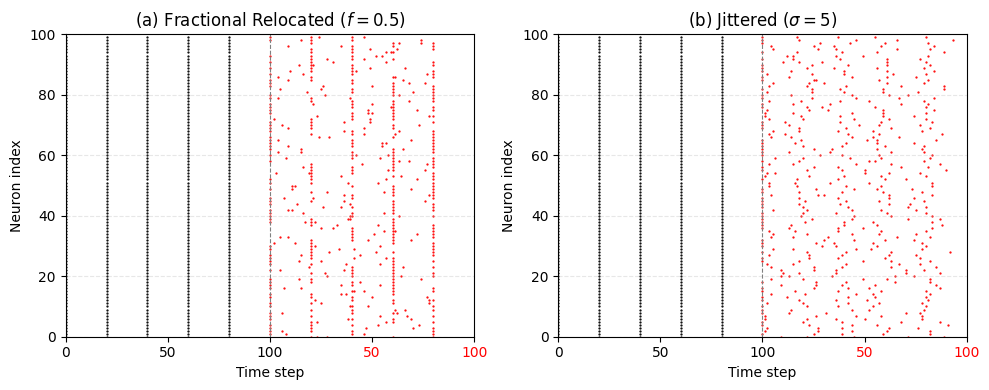

In [12]:
# Figure 1: the two timing-only perturbations at (near-)fixed spike count.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

draw_side_by_side(
    axes[0],
    original_spikes,
    relocated,
    rf"(a) Fractional Relocated ($f={RELOCATION_F:g}$)",
)
draw_side_by_side(
    axes[1],
    original_spikes,
    jittered,
    rf"(b) Jittered ($\sigma={JITTER_SIGMA:g}$)",
)

plt.tight_layout()
plt.savefig(
    "perturbation_relocation_jitter_visualization.png", dpi=150, bbox_inches="tight"
)
plt.show()

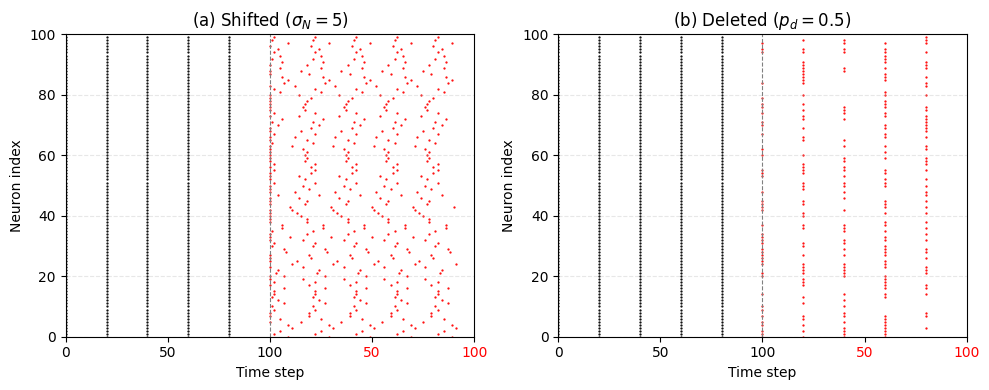

In [13]:
# Figure 2: block displacement (ISI preserved) vs. outright loss of drive.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

draw_side_by_side(
    axes[0],
    original_spikes,
    shifted,
    rf"(a) Shifted ($\sigma_N={SHIFT_SIGMA:g}$)",
)
draw_side_by_side(
    axes[1],
    original_spikes,
    deleted,
    rf"(b) Deleted ($p_d={DELETION_P:g}$)",
)

plt.tight_layout()
plt.savefig(
    "perturbation_shift_deletion_visualization.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Figure 3 — time reversal (inverse) perturbation

The inverse perturbation (from `inverse_train.ipynb`) flips the entire
sample within its **sample-wide active window** — the segment between
the earliest and latest spike across all neurons. Every neuron is
flipped with the same `t -> t_start + t_end - t` transform, so spike
counts, per-neuron ISI, and cross-neuron coincidences are preserved;
only the causal direction of time is reversed. It therefore gets a
figure of its own: nothing else in the set leaves the code this intact.

Because a fixed-interval train is symmetric in time (reversing it changes
nothing visible), this panel uses a **random** spike train with an
increasing firing-rate ramp so the effect is clear: activity that builds
up toward the end of the window (black, left) becomes activity that
decays from the start after reversal (red, right).

Total spikes (original / reversed): 510 / 510


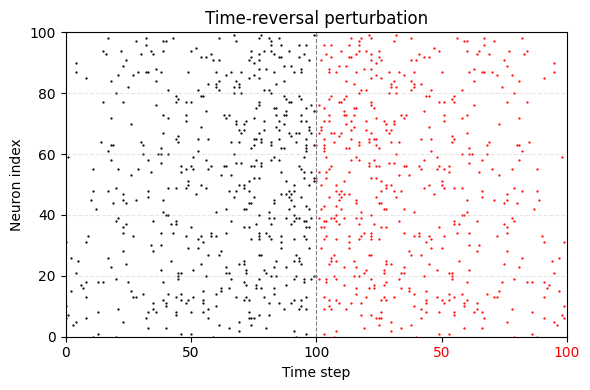

In [14]:
# The fixed-interval train used above is symmetric in time, so reversing it
# leaves the raster visually unchanged. Use a random train with a temporal
# firing-rate ramp instead: neurons fire at irregular, unsynchronised times
# and overall activity increases across the window, so the reversal is clearly
# visible (the build-up toward the end flips to a build-up at the start).
REVERSAL_RATE_RAMP = 6.0

reversal_input = make_random_spike_train(
    NUM_NEURONS, TIME_STEPS, FIRING_RATE,
    rate_ramp=REVERSAL_RATE_RAMP,
    seed=RNG_SEED,
)
reversed_spikes = reverse_spike_train(reversal_input)
print(
    f"Total spikes (original / reversed): "
    f"{int(reversal_input.sum())} / {int(reversed_spikes.sum())}"
)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
draw_side_by_side(
    ax,
    reversal_input,
    reversed_spikes,
    "Time-reversal perturbation",
)

plt.tight_layout()
plt.savefig("perturbation_inverse_visualization.png", dpi=150, bbox_inches="tight")
plt.show()